# 🤖 Machine Learning — From Scratch to Python Libraries

Welcome to the Machine Learning session! This notebook follows our Computer Vision course.

---

## 📚 Learning Outcomes

By the end of this notebook, you will be able to:
- Understand **what Machine Learning is** and why it matters
- Know the difference between **supervised**, **unsupervised**, and **reinforcement** learning
- Build simple ML models **from scratch** using only NumPy
- Use **scikit-learn** to train models quickly and efficiently
- Apply ML to a **real computer vision project**

---

> 💡 **Tip for beginners:** Read every markdown cell carefully before running the code. Each concept builds on the previous one!

## 🔧 Install & Import Libraries

Let's make sure we have everything we need. Run this cell first!

In [10]:
# Install required libraries (run once)
# Uncomment the line below if you haven't installed these yet

!pip install numpy matplotlib scikit-learn opencv-python seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 2.8 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
# --- Import libraries ---
import numpy as np                        # For math and arrays
import matplotlib.pyplot as plt           # For plotting graphs
import cv2                                # OpenCV for images
from sklearn import datasets              # Built-in datasets
from sklearn.model_selection import train_test_split  # Split data
from sklearn.preprocessing import StandardScaler      # Normalize data
from sklearn.metrics import accuracy_score, confusion_matrix  # Evaluate models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
# PART 1 — Theory of Machine Learning

## 🧠 What is Machine Learning?

Traditional programming: **You write rules → Computer follows them**

Machine Learning: **You give data → Computer learns the rules itself**

```
Traditional:  Input + Rules  → Output
ML:           Input + Output → Rules (Model)
```

### 📦 The 3 Types of Machine Learning

| Type | Description | Example |
|------|-------------|----------|
| **Supervised** | Learns from labeled data (input + answer) | Classify images as cat/dog |
| **Unsupervised** | Finds patterns in data with no labels | Group similar images together |
| **Reinforcement** | Learns by trial and error (reward/penalty) | Game-playing AI |

In this course, we focus on **Supervised Learning**.

---

## 📊 Key Vocabulary

- **Feature (X):** The input data (e.g., pixel values of an image)
- **Label (y):** The answer we want to predict (e.g., "cat" or "dog")
- **Training set:** Data used to teach the model
- **Test set:** New data used to check how well the model learned
- **Model:** The mathematical function that maps X → y
- **Loss:** How wrong the model's predictions are (we want to minimize this!)

Shape of X (features): (100, 2)  → 100 samples, 2 features each
Shape of y (labels):   (100,)  → 100 labels (0 or 1)
First 3 samples: [[1.49671415 0.8617357 ]
 [1.64768854 2.52302986]
 [0.76584663 0.76586304]]
First 3 labels:  [0 0 0]


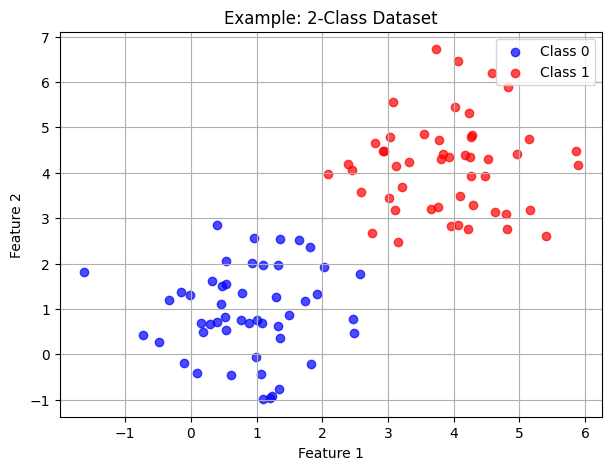

In [3]:
# -------------------------------------------------------
# Let's visualize what "features" and "labels" look like
# We use a simple 2D example with two classes
# -------------------------------------------------------

np.random.seed(42)  # Makes results reproducible

# Generate two clusters of points (two classes)
class_0 = np.random.randn(50, 2) + np.array([1, 1])   # Class 0: centered at (1,1)
class_1 = np.random.randn(50, 2) + np.array([4, 4])   # Class 1: centered at (4,4)

# Stack them together into one dataset
X = np.vstack([class_0, class_1])          # Features: shape (100, 2)
y = np.array([0]*50 + [1]*50)              # Labels: 50 zeros, then 50 ones

print(f'Shape of X (features): {X.shape}  → 100 samples, 2 features each')
print(f'Shape of y (labels):   {y.shape}  → 100 labels (0 or 1)')
print(f'First 3 samples: {X[:3]}')
print(f'First 3 labels:  {y[:3]}')

# Plot the data
plt.figure(figsize=(7, 5))
plt.scatter(class_0[:, 0], class_0[:, 1], color='blue', label='Class 0', alpha=0.7)
plt.scatter(class_1[:, 0], class_1[:, 1], color='red',  label='Class 1', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Example: 2-Class Dataset')
plt.legend()
plt.grid(True)
plt.show()

---
## 🔀 Train / Test Split

We **never** test a model on data it has already seen during training — that would be cheating!

We split our data:
- **80% → Training set** (model learns from this)
- **20% → Test set** (we evaluate on this, model never saw it)

In [4]:
# Splitting the dataset into training and testing sets using numpy (without sklearn)

test_size = 0.2
rng = np.random.RandomState(42)

n_samples = X.shape[0]
n_test = int(np.ceil(test_size * n_samples))

indices = rng.permutation(n_samples)
test_indices = indices[:n_test]
train_indices = indices[n_test:]

X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')

print("3 first training samples:\n", X_train[:3])
print("3 first training labels:\n", y_train[:3])

Training set: 80 samples
Testing set:  20 samples
3 first training samples:
 [[2.08122878 3.97348612]
 [4.01300189 5.45353408]
 [0.323078   1.61167629]]
3 first training labels:
 [1 1 0]


In [5]:
# -------------------------------------------------------
# Split data into training and testing sets
# test_size=0.2 means 20% goes to testing
# random_state=42 makes the split reproducible
# -------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing  samples: {X_test.shape[0]}')
print()
print('💡 The model will only learn from X_train and y_train.')
print('   X_test and y_test are "hidden" until evaluation time.')

print("3 first training samples:\n", X_train[:3])
print("3 first training labels:\n", y_train[:3])

Training samples: 80
Testing  samples: 20

💡 The model will only learn from X_train and y_train.
   X_test and y_test are "hidden" until evaluation time.
3 first training samples:
 [[2.08122878 3.97348612]
 [4.01300189 5.45353408]
 [0.323078   1.61167629]]
3 first training labels:
 [1 1 0]


---
# PART 2 — Simple Models From Scratch

## 📏 Model 1: Linear Regression (From Scratch)

**Goal:** Predict a continuous number (e.g., predict house price from size)

The formula is: `ŷ = w * x + b`
- `w` = weight (slope)
- `b` = bias (intercept)
- We find the best `w` and `b` by minimizing the **Mean Squared Error (MSE)**:

`MSE = (1/n) * Σ (y - ŷ)²`

We update weights using **Gradient Descent**:
- Move `w` and `b` a tiny step in the direction that reduces the error

In [ ]:
# Class Work

---
## 📏 Model 1: Linear Regression (Houses Example)

**Goal:** Predict house price (€k) from house size (m²)

Formula: `ŷ = w·x + b`

Loss (MSE): `L = (1/n) Σ (y − ŷ)²`

Gradient Descent: `w ← w − α · ∂L/∂w`

We will:
1. Build the model from scratch step by step
2. **Print** weight, bias, and loss every 100 steps
3. **Animate** the regression line improving over iterations

In [ ]:
# Class Work

---
## 🔵 Model 2: Logistic Regression (From Scratch)

**Goal:** Predict a class (0 or 1) — this is **classification**

We use the **sigmoid function** to squish any number into [0, 1]:

`σ(z) = 1 / (1 + e^(-z))`

The model: `ŷ = σ(w·x + b)`

If `ŷ > 0.5` → predict class 1, else → predict class 0

In [ ]:
# Class Work

---
## 🔵 Model 2: Logistic Regression (Real Data — Breast Cancer)

**Goal:** Classify whether a tumour is **malignant (1)** or **benign (0)**

We use the **Wisconsin Breast Cancer dataset** — real medical data:
- 569 samples, 30 features per sample (e.g., tumour radius, texture, area...)
- **No random data** — these are real hospital measurements!

We will:
1. Train from scratch step by step
2. **Animate** how the decision boundary changes during training
3. Compare with scikit-learn's version

In [ ]:
# Class Work

---
## 🌳 Model 3: K-Nearest Neighbors (From Scratch)

**Idea:** To classify a new point, look at the **K closest neighbors** and take a vote!

- If `K=3` and 2 neighbors are class 0, 1 is class 1 → predict class 0
- Distance is computed with **Euclidean distance**: `d = √(Σ(x₁-x₂)²)`

**No training needed!** KNN just memorizes all the data.

In [ ]:
# Class Work

---
# PART 3 — Using scikit-learn (Python Library)

Now that we understand **how** these models work, let's use `scikit-learn` — a library that implements all of these models efficiently and with more features!

All scikit-learn models follow the same pattern:
```python
model = SomeModel(parameters)
model.fit(X_train, y_train)      # train
predictions = model.predict(X_test)  # predict
```

In [ ]:
# Class Work

---
## Use breast cancer full 30-feature dataset

Now that we understand **how** models work, let's use scikit-learn — same results, 3 lines of code!

```python
model = SomeModel(params)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
```

In [ ]:
# Class Work

---
## 🔍 Understanding Overfitting vs Underfitting

| Situation | What's happening | Fix |
|-----------|-----------------|-----|
| **Underfitting** | Model is too simple, can't learn patterns | Use a more complex model |
| **Good fit** | Model learns real patterns | ✅ |
| **Overfitting** | Model memorizes training data, fails on new data | Use regularization, more data |

In [ ]:
# -------------------------------------------------------
# Visualize overfitting with a Decision Tree
# A very deep tree memorizes every training point!
# -------------------------------------------------------

depths = [1, 3, 10, None]   # None means no limit (full tree)
labels = ['Depth=1 (Underfit)', 'Depth=3 (Good)', 'Depth=10 (Overfit)', 'No limit (Very Overfit)']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, depth, label in zip(axes, depths, labels):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc  = accuracy_score(y_test,  tree.predict(X_test))
    
    # Plot decision boundary
    h = 0.05
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=20)
    ax.set_title(f'{label}\nTrain: {train_acc*100:.0f}%  Test: {test_acc*100:.0f}%', fontsize=9)

plt.suptitle('Overfitting Demo with Decision Trees', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# PART 4 — Real Project: Digit Classification with ML

## 🖼️ Project: Classify Handwritten Digits (0-9)

We'll use the famous **MNIST-style digits dataset** from scikit-learn.

Each image is 8×8 pixels = 64 features. Our ML model has to predict which digit it is!

This is a real computer vision task — and it's a preview of what Deep Learning does much better 😉

Dataset shape: (1797, 8, 8)
Number of classes: 10  →  digits 0-9


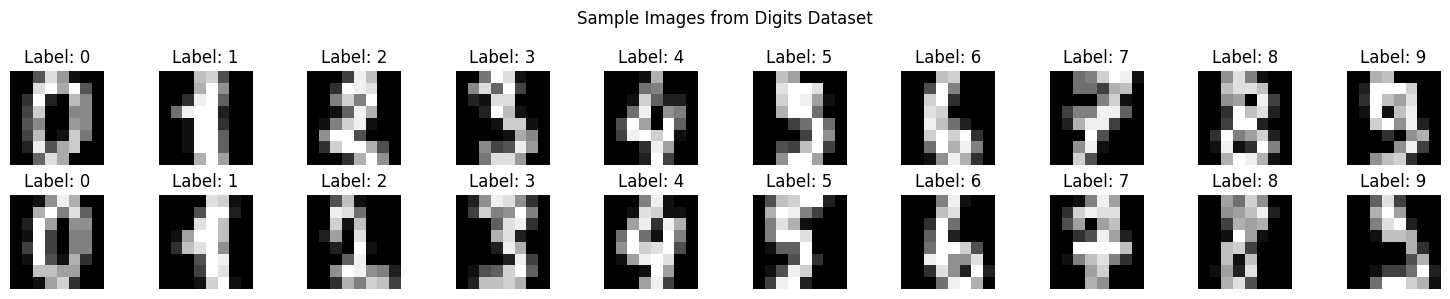

In [6]:
# -------------------------------------------------------
# Load the digits dataset
# -------------------------------------------------------

digits = datasets.load_digits()

print(f'Dataset shape: {digits.images.shape}')   # (1797, 8, 8)
print(f'Number of classes: {len(np.unique(digits.target))}  →  digits 0-9')

# Visualize some digits
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')
plt.suptitle('Sample Images from Digits Dataset', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# -------------------------------------------------------
# Prepare data: flatten each 8x8 image into 64 features
# -------------------------------------------------------

# Reshape images: (1797, 8, 8) → (1797, 64)
X_digits = digits.images.reshape(len(digits.images), -1)
y_digits = digits.target

print(f'Feature shape after flattening: {X_digits.shape}')

# Split into train/test
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42
)

# Normalize pixel values to [0, 1]
# This helps most ML models work better!
scaler = StandardScaler()
X_train_d = scaler.fit_transform(X_train_d)   # fit on train, transform train
X_test_d  = scaler.transform(X_test_d)        # only transform test (never fit!)

# --- Train several models and compare ---
digit_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'KNN (k=3)':           KNeighborsClassifier(n_neighbors=3),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF kernel)':    SVC(kernel='rbf', C=10),
}

print('Digit Classification Results')
print('=' * 40)

best_model = None
best_acc = 0

for name, model in digit_models.items():
    model.fit(X_train_d, y_train_d)
    acc = accuracy_score(y_test_d, model.predict(X_test_d))
    print(f'{name:<25}  Accuracy: {acc*100:.2f}%')
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_name = name

print(f'\n🏆 Best model: {best_name}  ({best_acc*100:.2f}%)')

Feature shape after flattening: (1797, 64)
Digit Classification Results
Logistic Regression        Accuracy: 97.22%
KNN (k=3)                  Accuracy: 96.94%
Random Forest              Accuracy: 97.22%
SVM (RBF kernel)           Accuracy: 98.06%

🏆 Best model: SVM (RBF kernel)  (98.06%)


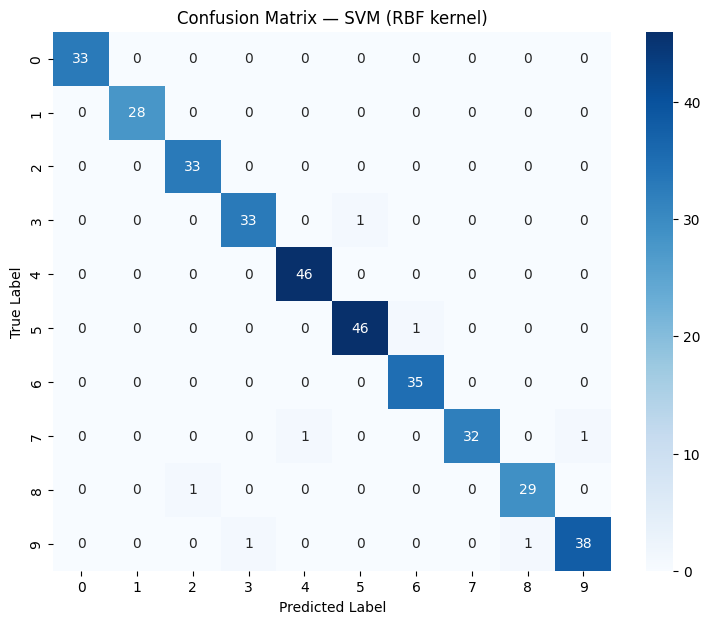


Misclassified: 7 out of 360


In [11]:
# -------------------------------------------------------
# Confusion Matrix: see which digits get confused!
# -------------------------------------------------------
import seaborn as sns

y_pred_best = best_model.predict(X_test_d)
cm = confusion_matrix(y_test_d, y_pred_best)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

# Show some misclassified examples
wrong_indices = np.where(y_pred_best != y_test_d)[0]

print(f'\nMisclassified: {len(wrong_indices)} out of {len(y_test_d)}')

if len(wrong_indices) >= 10:
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, idx in enumerate(wrong_indices[:10]):
        ax = axes[i // 5, i % 5]
        img = scaler.inverse_transform(X_test_d[idx].reshape(1, -1)).reshape(8, 8)
        ax.imshow(img, cmap='gray')
        ax.set_title(f'True:{y_test_d[idx]}  Pred:{y_pred_best[idx]}', color='red')
        ax.axis('off')
    plt.suptitle('Misclassified Digits', fontsize=12)
    plt.tight_layout()
    plt.show()

---
# 🏋️ Exercises

### Exercise 1 — Tune KNN
Change K from 1 to 3, 7, 15 on the cancer dataset. How does accuracy change? What is the best K?

### Exercise 2 — Feature Engineering
For Linear Regression (houses), add a second feature: `rooms = house_sizes / 25`.
Does adding this feature improve R²?

### Exercise 3 — Iris Dataset
Load `datasets.load_iris()` — a 3-class flower classification. Train a Random Forest and show the confusion matrix.

### Exercise 4 — Cross-Validation
Use `cross_val_score(model, X, y, cv=10)` on the cancer dataset. Why is 10-fold CV better than a single split?

---
# ✅ Exercise Answers

In [ ]:
# ✏️ Your code here for Exercise 1



In [ ]:
# ✏️ Your code here for Exercise 2



In [ ]:
# ✏️ Your code here for Exercise 3



In [ ]:
# ✏️ Your code here for Exercise 4



---
# 📝 Quiz

1. What is the difference between **classification** and **regression**?
2. Why do we split data into train and test sets?
3. What happens if K=1 in KNN? Is that good or bad?
4. What is **overfitting**? Give one way to prevent it.
5. Why do we **normalise** (standardise) features before training?

> 💡 Bonus: Can you think of a CV problem that could benefit from ML classification?

✏️ **Your answers here:**

1. 
2. 
3. 
4. 
5. 

---
# 🎉 Summary

Congratulations! In this notebook you learned:

| Concept | What we did |
|---------|-------------|
| **ML Theory** | Supervised vs unsupervised, features/labels, train/test split |
| **Linear Regression** | Built from scratch with gradient descent |
| **Logistic Regression** | Built from scratch with sigmoid + cross-entropy |
| **KNN** | Built from scratch using Euclidean distance |
| **scikit-learn** | Used 5 models with the same simple API |
| **Real Project** | Classified handwritten digits (0-9) |
| **Overfitting** | Visualized with Decision Trees of different depths |

➡️ **Next session:** Deep Learning & Convolutional Neural Networks!

We'll see how CNNs dramatically outperform classical ML on images 🚀